### Importing necessary modules

In [47]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
import tensorflow as tf                                                                 # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore
import random                                                                           # type: ignore
import cartopy.crs as ccrs                                                              # type: ignore
import cartopy.feature as cfeature                                                      # type: ignore
#np.random.seed(42)                                      
from netCDF4 import Dataset                                                             # type: ignore

In [48]:
geodata = Dataset("/home/mendrika/mendrika-phd/codes/nflics/geoloc_grids/nxny1640_580_nxnyds164580_blobdx0.04491576_area4_n23_20_32.nc")

### Importing dataset

### Exploratory data analysis

In [49]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [50]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [51]:
# Presence or absence of convection in Dakar at time t+1
target_index = "Cb_Dakar"

# Input at time t0
t0 = "year,month,day,hour,minute,"

# latitude and longitude, wavelet power, storm size and distance to Dakar
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"

# combining all fields to form the feature input
features = t0 + location + wavelet_power + storm_size + distance
field =  features + target_index
field = field.split(',')

In [52]:
to_scale = wavelet_power + storm_size + distance

In [53]:
lead_time = 1

In [54]:
model = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/Bamako-t{lead_time}.keras")

In [55]:
scaler = load('/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/scaler-Bamako.bin')

In [56]:
raw_artificial_storm_data = pd.read_csv("test-data-from-latlon-map-Bamako.csv")

In [57]:
artificial_storm_data = log_transform(raw_artificial_storm_data, to_scale.split(',')[:-1])
artificial_storm_data = sqrt_transform(artificial_storm_data, t0.split(',')[:-1])
x_new = artificial_storm_data[raw_artificial_storm_data.keys()]
x_new_std = scaler.transform(x_new)
y_new_pred = model.predict(x_new_std)

300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [58]:
from scipy.ndimage import gaussian_filter  # type: ignore

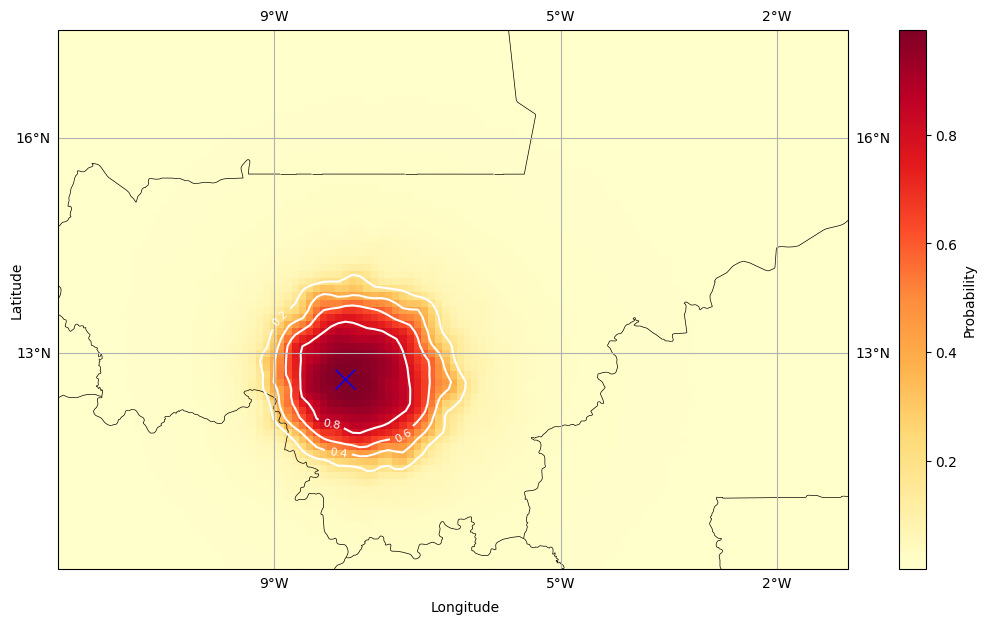

In [59]:
fig = plt.figure(figsize=(13, 7))


step = 0.1

longitude = np.arange(-12, 0, step)
latitude = np.arange(10, 18, step)

lons, lats = np.meshgrid(longitude, latitude)


ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-12, -1, 10, 17.5], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.gridlines(xlocs=np.array([-9, -5, -2]), ylocs=np.array([10, 13, 16]), draw_labels=True, crs=ccrs.PlateCarree())


prob = y_new_pred.flatten().reshape(lons.shape).round(4)
prob = gaussian_filter(prob, sigma=1)

plt.pcolormesh(lons, lats, prob, cmap="YlOrRd")
plt.colorbar(label='Probability')
contour = plt.contour(lons, lats, prob, colors='white', levels=5)
plt.clabel(contour, inline=True, fontsize=8)

Bamako_lon = -8.0029
Bamako_lat = 12.6392
plt.plot(Bamako_lon, Bamako_lat, "x", color="blue", markersize=15)

fig.text(0.45, 0.05, "Longitude", ha='center')
fig.text(0.1, 0.51, "Latitude", va='center', rotation='vertical')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
plt.show()